In [1]:
from PIL import Image
from torchvision import transforms
import numpy as np

In [2]:
def to_fashion_mnist(img_array: np.ndarray):
  image = Image.fromarray(img_array)
  invert = True

  # Build the transform pipeline
  transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # -> 1 channel
    transforms.Resize((28, 28)),  # -> 28x28
    transforms.RandomInvert(p=1.0 if invert else 0.0),  # invert if needed
    transforms.ToTensor(),  # -> [0,1], shape [1,28,28]
    transforms.Normalize((0.2860,), (0.3530,)),  # Fashion MNIST stats
  ])

  tensor = transform(image)
  tensor = tensor.unsqueeze(0)  # add batch dim -> [1, 1, 28, 28]
  return tensor

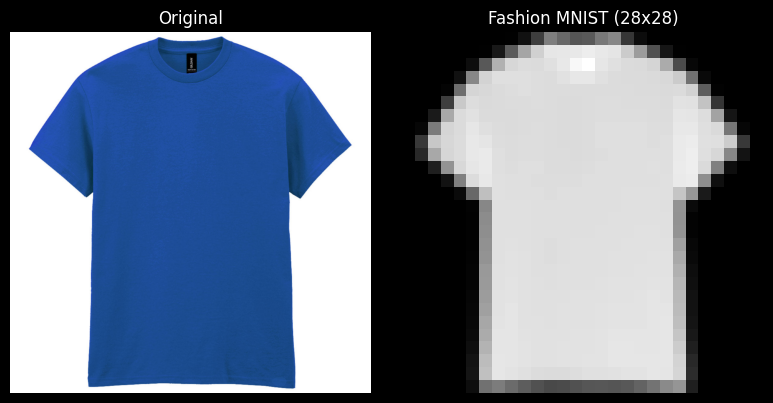

In [3]:
import matplotlib.pyplot as plt
import requests
from io import BytesIO

TEST_URL = 'https://www.militarykit.com/cdn/shop/files/mens-gildan-short-sleeve-heavy-cotton-tshirt-royal-blue.jpg?v=1766053652&width=1500'

response = requests.get(TEST_URL)
img = Image.open(BytesIO(response.content)).convert("RGBA")
img_array = np.array(img)

tensor = to_fashion_mnist(img_array)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_array)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(tensor.squeeze().numpy(), cmap="gray")
axes[1].set_title("Fashion MNIST (28x28)")
axes[1].axis("off")

plt.tight_layout()
plt.show()